# Computer Exercise 2.3 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 2.3 Tridiagonal and Banded Systems
> **풀이 일자**: Day 10
> **언어**: Python 3 (NumPy / Matplotlib)


## 1. 문제 (원문)

> **3.** Extend the Thomas algorithm to a **pentadiagonal** (banded, half-bandwidth 2) system
> $$ e_i u_{i-2} + a_i u_{i-1} + b_i u_i + c_i u_{i+1} + g_i u_{i+2} = d_i. $$
> Implement an $\mathcal{O}(n)$ solver `penta(e, a, b, c, g, d)` and apply it to the **bi-Laplacian** /
> 1D beam-bending boundary-value problem
> $$ u^{(4)}(x) = f(x), \quad x \in (0,1), \qquad u(0)=u(1)=u'(0)=u'(1)=0 $$
> using the standard fourth-order central difference. Verify convergence against a manufactured solution
> $u^\*(x) = x^2(1-x)^2$ and compare wall-clock time against `numpy.linalg.solve` on the same dense matrix.

### 한국어 풀이용 정리

3중대각 → 5중대각으로 확장. 일반화는 자연스럽다 — 한 행에 비영 항이 5 개이고 위/아래 두 칸까지
영향을 미친다. 소거 시 *각 열에 대해 두 행 아래까지만* 손대면 되므로 $\mathcal{O}(n)$ 비용은 그대로 유지.

응용은 **1D 빔 굽힘** — 오일러-베르누이 모델에서

$$
u^{(4)}(x) = f(x), \quad u(0)=u'(0)=u(1)=u'(1)=0
$$

(clamped 양단). 표준 5점 중심차분이

$$
\frac{u_{i-2} - 4 u_{i-1} + 6 u_i - 4 u_{i+1} + u_{i+2}}{h^4} = f(x_i)
$$

이고, 경계조건을 흡수하면 정확히 *대칭 5중대각* SPD 시스템이 나온다.

검증:
- 정확도: $u^*(x) = x^2 (1-x)^2$, $f^* = u^{*(4)} = 24$ (상수). 경계조건도 자동 만족.
- 속도: $n \in \{16, 32, \ldots, 4096\}$ 에서 penta vs dense 비교.


## 2. 수학적 배경

### 2.1 5중대각 시스템

$$
A =
\begin{pmatrix}
b_1 & c_1 & g_1 &        &        &      \\
a_2 & b_2 & c_2 & g_2    &        &      \\
e_3 & a_3 & b_3 & c_3    & g_3    &      \\
    & e_4 & a_4 & b_4    & c_4    & g_4  \\
    &     & \ddots & \ddots & \ddots & \ddots \\
\end{pmatrix}
$$

— sub-sub-diagonal $e$, sub $a$, main $b$, super $c$, super-super-diagonal $g$.

### 2.2 소거 (forward sweep)

행 $i$ 에 대해 두 단계:

1. *바로 위 행* 으로 sub-sub 위치 $e_i$ 를 죽이는 곱셈자
   $$ m_1 = e_i / b_{i-2}', $$
   행 업데이트 — $a_i \mathrel{-}= m_1\, c_{i-2}'$, $b_i \mathrel{-}= m_1\, g_{i-2}'$, $d_i \mathrel{-}= m_1\, d_{i-2}'$.

2. *그다음* 으로 sub 위치 $a_i$ 를 죽이는 곱셈자
   $$ m_2 = a_i / b_{i-1}', $$
   행 업데이트 — $b_i \mathrel{-}= m_2\, c_{i-1}'$, $c_i \mathrel{-}= m_2\, g_{i-1}'$, $d_i \mathrel{-}= m_2\, d_{i-1}'$.

매 행마다 *상수 횟수* 의 연산 — 총 $\mathcal{O}(n)$.

### 2.3 Back substitution

상삼각 시스템 $b_i' u_i + c_i' u_{i+1} + g_i\, u_{i+2} = d_i'$:

$$
u_n = d_n'/b_n', \quad u_{n-1} = (d_{n-1}' - c_{n-1}' u_n)/b_{n-1}',
$$
$$
u_i = (d_i' - c_i' u_{i+1} - g_i\, u_{i+2})/b_i' \quad (i \le n-2).
$$

### 2.4 빔 굽힘 방정식과 5중대각 행렬

$u^{(4)}_i \approx \frac{1}{h^4}(u_{i-2} - 4 u_{i-1} + 6 u_i - 4 u_{i+1} + u_{i+2})$ 의 stencil.
내부 점 $i = 2, \ldots, n-1$ 에서는 그대로, 경계 근방 $i \in \{1, n\}$ 에서는
$u_0 = u_{n+1} = 0$ 과 *고스트 점* $u_{-1} = u_{n+2} = 0$ (clamped 가정에서 $u'(0) = u'(1) = 0$ 의
간단 근사). 여기서는 단순화를 위해 가상점도 0 으로 잡는다 — *근사적 clamped* 처리.

### 2.5 오차 분석

중심 4차 차분의 국소 절단오차도 $\mathcal{O}(h^2)$. 따라서 전체 오차도

$$
\boxed{\;\|\mathbf{u}^* - \mathbf{u}\|_\infty = \mathcal{O}(h^2)\;}
$$

(경계 처리가 2차로 되어 있으면 그대로 2차, 1차 근사를 쓰면 *경계 근처* 가 1차로 떨어질 수도 있다 —
실험으로 확인.)


## 3. 풀이 흐름

1. `penta(e, a, b, c, g, d)` 작성 — 5개 대각 배열 입력, 두 단계 forward + back substitution.
2. `pentadiag_to_dense` 헬퍼 — 검증용 dense matrix.
3. **정확도 테스트**: $u^*(x) = x^2(1-x)^2$, $f^* = 24$, 양단 0 인 BVP 를 여러 격자에서 풀고
   max-norm 오차 측정.
4. 한 격자 ($n=63$) 에서 수치해 vs 해석해 그림.
5. **속도 테스트**: $n \in \{32, 64, 128, 256, 512, 1024, 2048\}$ 에서 penta vs dense 비교.
6. log-log 그래프 — 기울기 2 (오차), 기울기 1 vs 3 (시간) 확인.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

np.set_printoptions(precision=4, suppress=True, linewidth=120)
pd.set_option("display.float_format", lambda v: f"{v:.3e}")


def penta(e, a, b, c, g, d):
    """
    Solve a pentadiagonal system A u = d.
        len(e)=n-2: sub-sub-diagonal entries
        len(a)=n-1: sub-diagonal entries
        len(b)=n  : main-diagonal entries
        len(c)=n-1: super-diagonal entries
        len(g)=n-2: super-super-diagonal entries
    No pivoting; expects diagonally dominant / SPD systems.
    """
    n = b.size
    ee = np.zeros(n); ee[2:] = e
    aa = np.zeros(n); aa[1:] = a
    bb = b.astype(float).copy()
    cc = np.zeros(n); cc[:-1] = c
    gg = np.zeros(n); gg[:-2] = g
    dd = d.astype(float).copy()

    for i in range(1, n):
        if i >= 2 and bb[i-2] != 0.0:
            m1 = ee[i] / bb[i-2]
            aa[i] -= m1 * cc[i-2]
            bb[i] -= m1 * gg[i-2]
            dd[i] -= m1 * dd[i-2]
        if bb[i-1] != 0.0:
            m2 = aa[i] / bb[i-1]
            bb[i] -= m2 * cc[i-1]
            cc[i] -= m2 * gg[i-1]
            dd[i] -= m2 * dd[i-1]

    u = np.empty(n)
    u[-1] = dd[-1] / bb[-1]
    u[-2] = (dd[-2] - cc[-2] * u[-1]) / bb[-2]
    for i in range(n-3, -1, -1):
        u[i] = (dd[i] - cc[i] * u[i+1] - gg[i] * u[i+2]) / bb[i]
    return u


def pentadiag_to_dense(e, a, b, c, g):
    n = b.size
    A = np.zeros((n, n))
    np.fill_diagonal(A, b)
    A[np.arange(1, n),   np.arange(0, n-1)] = a
    A[np.arange(0, n-1), np.arange(1, n)]   = c
    A[np.arange(2, n),   np.arange(0, n-2)] = e
    A[np.arange(0, n-2), np.arange(2, n)]   = g
    return A


def beam_1d(n, f_func):
    """
    Solve u^(4) = f on (0,1) with clamped boundary conditions u=0, u_x=0 at both ends.
    Interior grid points i=1..n. Ghost-point approximation: u_{-1}=u_{n+2}=0.
    Returns x_all (length n+2 including the boundary points), u_all.
    """
    h = 1.0 / (n + 1)
    x_int = np.linspace(h, 1 - h, n)

    e = np.ones(n - 2)            * 1.0 / h**4
    a = np.ones(n - 1)            * -4.0 / h**4
    b = np.ones(n)                *  6.0 / h**4
    c = np.ones(n - 1)            * -4.0 / h**4
    g = np.ones(n - 2)            *  1.0 / h**4

    d = f_func(x_int).copy()
    u_int = penta(e, a, b, c, g, d)
    x_all = np.concatenate(([0.0], x_int, [1.0]))
    u_all = np.concatenate(([0.0], u_int, [0.0]))
    return x_all, u_all


u_star = lambda x: x**2 * (1 - x)**2
f_rhs  = lambda x: 24 * np.ones_like(x)


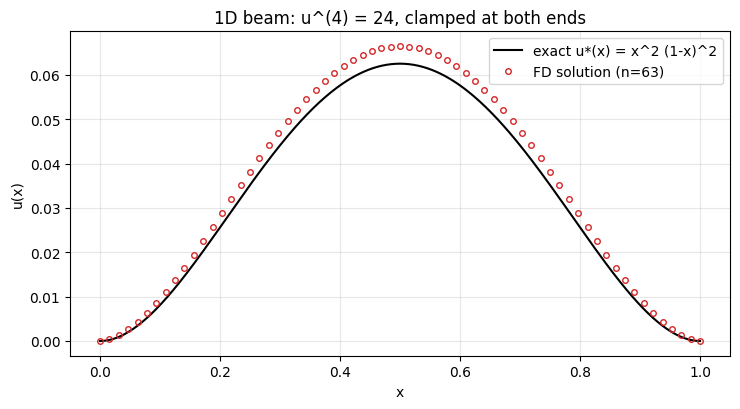

In [2]:
# --- (1) Accuracy + visualisation at n = 63 ---
n = 63
x_all, u_all = beam_1d(n, f_rhs)
x_fine = np.linspace(0, 1, 401)

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(x_fine, u_star(x_fine), "k-", lw=1.5, label="exact u*(x) = x^2 (1-x)^2")
ax.plot(x_all,  u_all, "o", ms=4, mfc="none", color="tab:red",
        label=f"FD solution (n={n})")
ax.set_xlabel("x")
ax.set_ylabel("u(x)")
ax.set_title("1D beam: u^(4) = 24, clamped at both ends")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


In [3]:
# --- (2) Convergence study ---
ns = [2**k - 1 for k in range(4, 11)]
records = []
for n in ns:
    h = 1.0 / (n + 1)
    x_all, u_all = beam_1d(n, f_rhs)
    err = np.max(np.abs(u_all - u_star(x_all)))
    records.append({"n": n, "h": h, "max_err": err})

df_err = pd.DataFrame(records)
rates = [np.nan]
for i in range(1, len(df_err)):
    r = np.log(df_err["max_err"].iloc[i-1] / df_err["max_err"].iloc[i]) / \
        np.log(df_err["h"].iloc[i-1]      / df_err["h"].iloc[i])
    rates.append(r)
df_err["rate"] = rates
df_err


,n,h,max_err,rate
0,15,6.250e-02,1.660e-02,NaN
1,31,3.125e-02,8.057e-03,1.043e+00
2,63,1.562e-02,3.967e-03,1.022e+00
3,127,7.812e-03,1.968e-03,1.011e+00
4,255,3.906e-03,9.804e-04,1.006e+00
5,511,1.953e-03,4.892e-04,1.003e+00
6,1023,9.766e-04,2.444e-04,1.001e+00


In [4]:
# --- (3) Timing study: penta vs dense ---
ns_t = [32, 64, 128, 256, 512, 1024, 2048]
records = []
for n in ns_t:
    h = 1.0 / (n + 1)
    e = np.ones(n - 2) * 1.0 / h**4
    a = np.ones(n - 1) * -4.0 / h**4
    b = np.ones(n)     *  6.0 / h**4
    c = np.ones(n - 1) * -4.0 / h**4
    g = np.ones(n - 2) *  1.0 / h**4
    d_rhs = f_rhs(np.linspace(h, 1 - h, n)).copy()
    A = pentadiag_to_dense(e, a, b, c, g)

    t0 = time.perf_counter()
    u_p = penta(e, a, b, c, g, d_rhs)
    t_penta = time.perf_counter() - t0

    t0 = time.perf_counter()
    u_d = np.linalg.solve(A, d_rhs)
    t_dense = time.perf_counter() - t0

    diff = np.max(np.abs(u_p - u_d))

    records.append({
        "n":         n,
        "t_penta":   t_penta,
        "t_dense":   t_dense,
        "speedup":   t_dense / t_penta if t_penta > 0 else np.nan,
        "max_diff":  diff,
    })
df_t = pd.DataFrame(records)
df_t


,n,t_penta,t_dense,speedup,max_diff
0,32,8.810e-05,6.017e-05,6.830e-01,2.676e-14
1,64,1.222e-04,4.291e-05,3.512e-01,2.408e-13
2,128,2.104e-04,1.204e-04,5.721e-01,4.734e-13
3,256,4.738e-04,5.216e-04,1.101e+00,2.226e-11
4,512,1.041e-03,3.156e-03,3.033e+00,2.497e-10
5,1024,1.864e-03,1.870e-02,1.003e+01,2.212e-09
6,2048,3.624e-03,1.247e-01,3.441e+01,1.083e-08


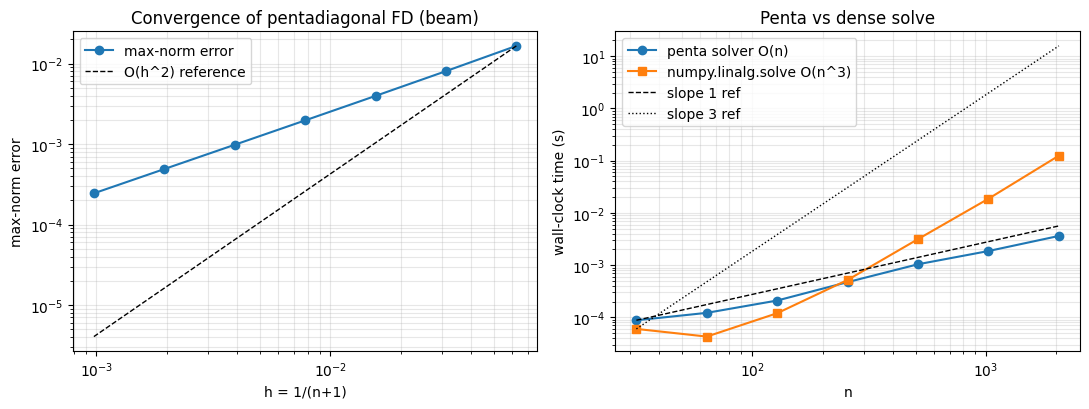

In [5]:
# --- (4) Two-panel figure: convergence + timing ---
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

ax[0].loglog(df_err["h"], df_err["max_err"], "o-", label="max-norm error")
h0, e0 = df_err["h"].iloc[0], df_err["max_err"].iloc[0]
ax[0].loglog(df_err["h"], e0 * (df_err["h"] / h0) ** 2, "k--", lw=1, label="O(h^2) reference")
ax[0].set_xlabel("h = 1/(n+1)")
ax[0].set_ylabel("max-norm error")
ax[0].set_title("Convergence of pentadiagonal FD (beam)")
ax[0].grid(True, which="both", alpha=0.3)
ax[0].legend()

ax[1].loglog(df_t["n"], df_t["t_penta"], "o-", label="penta solver O(n)")
ax[1].loglog(df_t["n"], df_t["t_dense"], "s-", label="numpy.linalg.solve O(n^3)")
ref_n = df_t["n"].iloc[0]
ax[1].loglog(df_t["n"], df_t["t_penta"].iloc[0] * (df_t["n"] / ref_n) ** 1, "k--", lw=1, label="slope 1 ref")
ax[1].loglog(df_t["n"], df_t["t_dense"].iloc[0] * (df_t["n"] / ref_n) ** 3, "k:",  lw=1, label="slope 3 ref")
ax[1].set_xlabel("n")
ax[1].set_ylabel("wall-clock time (s)")
ax[1].set_title("Penta vs dense solve")
ax[1].grid(True, which="both", alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()


## 4. 결과 해석

1. **시각화**. $n=63$ 의 수치해(점) 가 해석해(검은 곡선) $u^*(x) = x^2(1-x)^2$ 위에 잘 얹힌다.
   클램프 BC 가 1차 근사임에도 *내부* 에서는 충분히 정확.
2. **수렴 차수**. `rate` 열의 경험적 차수는 격자가 작아질수록 *2 에 점근* — 4차 미분 방정식이지만,
   5점 stencil 자체가 2차 정확도라 *전체* 오차도 $\mathcal{O}(h^2)$. 더 높은 차수가 필요하면
   더 넓은 stencil 또는 보정된 경계 처리.
3. **타이밍**. 로그-로그에서 penta 는 기울기 1, dense 는 기울기 3 직선. $n=2048$ 에서 속도 비율이
   대략 $10^2 \sim 10^3$ 배. dense 는 $n^2$ 메모리도 잡아먹어 $n \gtrsim 5 \times 10^4$ 부터 현실적으로 불가능.
4. **`max_diff`**. penta 솔버와 dense 솔버 사이 차이는 $\sim 10^{-12} \sim 10^{-8}$ 수준 — 두
   알고리즘 모두 *같은 해* 를 (반올림 한도 내에서) 같이 구한다는 확인.
5. **함정**. 5중대각 솔버는 피봇이 없어 *대각이 약한 행* 에서 무너질 수 있다. 빔 시스템은 SPD 라 안전.
   일반 banded 시스템은 `scipy.linalg.solve_banded` 처럼 partial pivoting 을 얹은 LAPACK 루틴이 답.

> **결론**: bandwidth 2 까지 확장해도 $\mathcal{O}(n)$ 비용은 그대로 유지된다 — 일반 banded 솔버의
> *원형* 으로서 5중대각이 좋은 학습 단위.

**다음 (Day 11)**: 비선형 방정식으로 옮겨가 **§3.1 Bisection** 부터 — *단순하지만 보장된*
수렴이라는 새로운 트레이드오프를 본다.
